# Comparando Modelos

Estamos en la  Clase 02
<br> El objetivo de la materia es lograr la mejor predicción para nuestro probleama, para lo que se probarán pipelines con decenas de alternativas, será indispensable comparar varios modelos predictivos entre sí y decidir cual es el mejor
<br> La tarea no es tan sencilla

## Seteo del ambiente en Google Colab

Esta parte se debe correr con el runtime en Python3
<br>Ir al menu, Runtime -> Change Runtime Type -> Runtime type ->  **Python 3**

Conectar la virtual machine donde esta corriendo Google Colab con el  Google Drive, para poder tener persistencia de archivos

In [1]:
# primero establecer el Runtime de Python 3
from google.colab import drive
drive.mount('/content/.drive')

Mounted at /content/.drive


<br>los siguientes comandos estan en shell script de Linux
*   Crear las carpetas en el Google Drive
*   Bajar el  **competencia_01_crudo**  al  Google Drive  y tambien al disco local de la virtual machine que esta corriendo Google Colab



In [2]:
%%shell

mkdir -p "/content/.drive/My Drive/dmeyf"
mkdir -p "/content/buckets"
ln -sfn "/content/.drive/My Drive/dmeyf" /content/buckets/b1


mkdir -p /content/buckets/b1/exp
mkdir -p /content/buckets/b1/datasets
mkdir -p /content/datasets


# defino funcion descargar()
descargar() {
  carpeta_destino="/content/buckets/b1/datasets/"
  url_origen="https://storage.googleapis.com/open-courses/dmeyf2026-9c6f/"
  archivo="$1"

  if ! test -f "$carpeta_destino""$archivo"; then
    wget  "$url_origen""$archivo"  -O "$carpeta_destino""$archivo"
  fi

  if ! test -f  "/content/datasets/""$archivo"; then
    cp  "$carpeta_destino""$archivo"  "/content/datasets/""$archivo"
  fi;
}


# hago la descarga efectiva, llamando a descargar()
descargar  "competencia_01_crudo.csv"

## Generacion de la clase_ternaria

Esta parte se debe correr con el runtime en lenguaje **R** Ir al menu, Runtime -> Change Runtime Type -> Runtime type -> R

In [1]:
require( "data.table" )

# leo el dataset
dataset <- fread("/content/datasets/competencia_01_crudo.csv" )

# calculo el periodo0 consecutivo
dsimple <- dataset[, list(
    "pos" = .I,
    numero_de_cliente,
    periodo0 = as.integer(foto_mes/100)*12 +  foto_mes%%100 ) ]


# ordeno
setorder( dsimple, numero_de_cliente, periodo0 )

# calculo topes
periodo_ultimo <- dsimple[, max(periodo0) ]
periodo_anteultimo <- periodo_ultimo - 1


# calculo los leads de orden 1 y 2
dsimple[, c("periodo1", "periodo2") :=
    shift(periodo0, n=1:2, fill=NA, type="lead"),  numero_de_cliente ]

# assign most common class values = "CONTINUA"
dsimple[ periodo0 < periodo_anteultimo, clase_ternaria := "CONTINUA" ]

# calculo BAJA+1
dsimple[ periodo0 < periodo_ultimo &
    ( is.na(periodo1) | periodo0 + 1 < periodo1 ),
    clase_ternaria := "BAJA+1" ]

# calculo BAJA+2
dsimple[ periodo0 < periodo_anteultimo & (periodo0+1 == periodo1 )
    & ( is.na(periodo2) | periodo0 + 2 < periodo2 ),
    clase_ternaria := "BAJA+2" ]


# pego el resultado en el dataset original y grabo
setorder( dsimple, pos )
dataset[, clase_ternaria := dsimple$clase_ternaria ]

fwrite( dataset,
    file =  "/content/datasets/competencia_01.csv.gz",
    sep = ","
)

Loading required package: data.table


Attaching package: ‘data.table’


The following object is masked from ‘package:base’:

    %notin%




In [2]:
setorder( dataset, foto_mes, clase_ternaria, numero_de_cliente)
dataset[, .N, list(foto_mes, clase_ternaria)]

foto_mes,clase_ternaria,N
<int>,<chr>,<int>
202103,BAJA+1,1019
202103,BAJA+2,960
202103,CONTINUA,160921
202104,BAJA+1,964
202104,BAJA+2,1139
202104,CONTINUA,161181
202105,BAJA+1,1143
202105,BAJA+2,870
202105,CONTINUA,161755


# 1  Particion Training/Testing
## Clase 02  Experimento 1

## 1.1  Objetivos
Dado que es el primer experimento de la asignatura, acercar a l@s estudiantes las mejores prácticas de operación del ambiente de Google Cloud, realizando una minuciosa demostración en vivo narrando todas las consideraciones pertinentes para evitar accidentes, daños a terceros y a equipos.
Dar soporte en el acto a  l@s estudiantes que necesitan ayuda para terminar de configurar el ambiente Google Cloud .
<br>Repaso del concepto de  partición de un dataset al azar, estratificada en la clase
<br>Dado que es el primer script que se mostrará en vivo a l@s estudiantes,  realizar una visita guiada del  mismo, su estructura y detalles.
<br>Repaso del algoritmo Arbol de Decisión sus hiperparámetros, y la implementación con la librería  rpart.  Funciones  rpart::rpart  y rpart::predict
<br>Concepto de replicabilidad de los experimentos mediante las semillas de los generadores de secuencias de números pseudoaleatorios.
<br>Finalmente, el principal objetivo de este experimento es lograr que l@s estudiantes dimensionen la enorme variabilidad del error de medición de la ganancia de un árbol de decisión al realizar una partición <training, testing>,  contener la sorpresa de los estudiantes, descartar a la simple particion <training, testing> como método,  y construir en conjunto una solucion natural al problema.

## 1.2 Introduccion

![Particiohn Training/Testing](https://storage.googleapis.com/open-courses/austral2025-af91/labo1r/C2_E1_particion.jpg)

![Dos tipos de error](https://storage.googleapis.com/open-courses/austral2025-af91/labo1r/C2_E1_target.jpg)

## 1.3  Bibliografía

Demšar, J. [Statistical comparisons of classifiers over multiple data sets](https://www.jmlr.org/papers/volume7/demsar06a/demsar06a.pdf) J. Mach. Learn. Res. 7, 1–30 (2006).   
Starmer, J. [Machine Learning Fundamentals: Cross Validation](https://www.youtube.com/watch?v=fSytzGwwBVw)Machine Learning Fundamentals: Cross Validation, StatQuest with Josh Starmer youtube channel, (2018)
Hastie, T.[The elements of statistical learning: data mining, inference, and prediction](https://hastie.su.domains/Papers/ESLII.pdf) , volume 2. Springer, 2009  ( Chapter 7 Model Assessment and Selection )

## 1.4 Codigo

Esta parte se debe correr con el runtime en lenguaje **R** Ir al menu, Runtime -> Change Runtime Type -> Runtime type -> R

limpio el ambiente de R

In [ ]:
# limpio la memoria
rm(list=ls(all.names=TRUE)) # remove all objects
gc(full=TRUE, verbose=FALSE) # garbage collection

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,739828,39.6,1473300,78.7,1473300,78.7
Vcells,1387924,10.6,170859532,1303.6,212615771,1622.2


In [ ]:
Sys.time()

[1] "2026-08-22 18:47:36 UTC"

* Instalacion de la libreria  rpart.plot  para dibujar el arbol
* invocacion de las librerias  **data.table** y  **rpart**

In [ ]:
# cargo las librerias que necesito
require("data.table")
require("rpart")

Loading required package: rpart



In [ ]:
if(!require("R.utils")) install.packages("R.utils")
require("R.utils")

Loading required package: R.utils

Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
“there is no package called ‘R.utils’”
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘R.oo’, ‘R.methodsS3’


Loading required package: R.utils

Loading required package: R.oo

Loading required package: R.methodsS3

R.methodsS3 v1.8.2 (2022-06-13 22:00:14 UTC) successfully loaded. See ?R.methodsS3 for help.

R.oo v1.27.1 (2025-05-02 21:00:05 UTC) successfully loaded. See ?R.oo for help.


Attaching package: ‘R.oo’


The following object is masked from ‘package:R.methodsS3’:

    throw


The following objects are masked from ‘package:methods’:

    getClasses, getMethods


The following objects are masked from ‘package:base’:

    attach, detach, load, save


R.utils v2.13.0 (2025-02-24 21:20:02 UTC) successfully loaded. See ?R.utils for help.


Attaching package: ‘R.utils’


The fol

###  Accion a Realizar
PARAM$semilla  debe tener su primer semilla aleatoria

In [ ]:
PARAM <- list()
PARAM$semilla <- 230047  # aqui debe ir su primer semilla
PARAM$training_pct <- 70L  # entre  1L y 99L

PARAM$rpart <- list (
  "cp" = -1, # complejidad minima
  "minsplit" = 170, # minima cantidad de regs en un nodo para hacer el split
  "minbucket" = 70, # minima cantidad de regs en una hoja
  "maxdepth" = 7 # profundidad máxima del arbol
)


In [ ]:
# particionar agrega una columna llamada fold a un dataset
#  que consiste en una particion estratificada segun agrupa

# particionar( data=dataset, division=c(70,30),
#  agrupa=clase_ternaria, seed=semilla)   crea una particion 70, 30

particionar <- function(
    data, division, agrupa = "",
    campo = "fold", start = 1, seed = NA) {
  if (!is.na(seed)) set.seed(seed)

  bloque <- unlist(mapply(function(x, y) {
    rep(y, x)
  }, division, seq(from = start, length.out = length(division))))

  data[, (campo) := sample(rep(bloque, ceiling(.N / length(bloque))))[1:.N],
    by = agrupa
  ]
}


In [ ]:
# carpeta de trabajo
setwd("/content/buckets/b1/exp")
experimento <- "exp0201"
dir.create(experimento, showWarnings=FALSE)
setwd( paste0("/content/buckets/b1/exp/", experimento ))

In [ ]:
# lectura del dataset
dataset <- fread("/content/datasets/competencia_01.csv.gz")
nrow(dataset)

[1] 983061

In [ ]:
# trabajo solo con los datos de 202106, ultimo mes con clase_ternaria completa
# filtro datos
dataset <- dataset[foto_mes==202106]

invisible(gc(full=TRUE, verbose=FALSE)) # garbage collection

nrow(dataset)
dataset[, .N, clase_ternaria]

[1] 164114

clase_ternaria,N
<chr>,<int>
CONTINUA,162142
BAJA+2,1098
BAJA+1,874


In [ ]:
# particiono estratificadamente el dataset 70%, 30%
particionar(dataset,
  division = c(PARAM$training_pct, 100L -PARAM$training_pct),
  agrupa = "clase_ternaria",
  seed = PARAM$semilla # aqui se usa SU semilla
)

In [ ]:
# genero el modelo
# quiero predecir clase_ternaria a partir del resto
# fold==1  es training,  el 70% de los datos
modelo <- rpart("clase_ternaria ~ .",
  data= dataset[fold == 1],  # fold==1  es training, el 70% de los datos
  xval= 0,
  control= PARAM$rpart # aqui van los parametros
)


In [ ]:
# aplico el modelo a los datos de testing
prediccion <- predict(modelo, # el modelo que genere recien
  dataset[fold == 2], # fold==2  es testing, el 30% de los datos
  type= "prob"
) # type= "prob"  es que devuelva la probabilidad


In [ ]:
tb_prediccion <- as.data.table(list(
  "clase_ternaria"=dataset[fold == 2, clase_ternaria],
  "prob"= prediccion[, "BAJA+2"]
))

In [ ]:
# calculo la ganancia de cada registro
tb_prediccion[, ganancia := ifelse(clase_ternaria == "BAJA+2", 1072500, -27500)]

In [ ]:
# calculo la clase
tb_prediccion[, Predicted := prob > (1/40) ]

In [ ]:
ganancia_test <-  tb_prediccion[ Predicted==TRUE,  sum(ganancia)]

In [ ]:
# normalizo la ganancia
ganancia_test_normalizada <- ganancia_test / (( 100 - PARAM$training_pct ) / 100 )

In [ ]:
estimulos <- tb_prediccion[ Predicted==TRUE, .N]
aciertos <- tb_prediccion[ Predicted & clase_ternaria == "BAJA+2", .N]


In [ ]:
# Resultado Final
cat("Testing total: ", dataset[fold == 2, .N], "\n")
cat("Testing BAJA+2: ", dataset[fold == 2 & clase_ternaria == "BAJA+2", .N], "\n")

cat("Estimulos: ", estimulos, "\n")
cat("Aciertos (BAJA+2): ", aciertos, "\n")

cat("Ganancia en testing (normalizada): ", ganancia_test_normalizada, "\n")


Testing total:  49233 
Testing BAJA+2:  328 
Estimulos:  3299 
Aciertos (BAJA+2):  171 
Ganancia en testing (normalizada):  324591667 


### Acciones a realizar
* Reportar la  *Ganancia en testing (normalizada)* <br> en la planilla colaborativa hoja  **C2-1sem**
* Se discutirá en clase la variabilidad de las ganancias obtenidas de distintos alumnos



---



# 2  Medición Monte Carlo Cross Validation
## Clase 02  Experimento 2

## 2.1  Objetivos
Mostrar el funcionamiento de la Montecarlo Cross Validation y que l@s estudiantes aprecien la disminución de la varianza de dicha metodología.
Relación con el Teorema Central del Límite

## 2.2 Introduccion

![Montecarlo](https://storage.googleapis.com/open-courses/austral2025-af91/labo1r/C2_E2_montecarlo.jpg)

![Curva normal](https://storage.googleapis.com/open-courses/austral2025-af91/labo1r/C2_E2_normal.jpg)

![Teorema Central del Limite](https://storage.googleapis.com/open-courses/austral2025-af91/labo1r/C2_E2_teoremacentralLimite.jpg)



## 2.3  Bibliografía

Demšar, J. [Statistical comparisons of classifiers over multiple data sets](https://www.jmlr.org/papers/volume7/demsar06a/demsar06a.pdf) J. Mach. Learn. Res. 7, 1–30 (2006).   
Starmer, J. [Machine Learning Fundamentals: Cross Validation](https://www.youtube.com/watch?v=fSytzGwwBVw)Machine Learning Fundamentals: Cross Validation, StatQuest with Josh Starmer youtube channel, (2018)
Hastie, T.[The elements of statistical learning: data mining, inference, and prediction](https://hastie.su.domains/Papers/ESLII.pdf) , volume 2. Springer, 2009  ( Chapter 7 Model Assessment and Selection )

## 2.4 Codigo  Montecarlo

El código de la Montecarlo Cross Validation es notablemente más complejo que el anterior de una simple partición training/testing
<br> Se crea la funcion ArbolEstimarGanancia()  que dada una semilla realiza la partición  training/testing, entrena en training, aplica el modelo a testing, y se calculan las ganancias
<br> Se utiliza la funcion **mcmapply**  de R para aplicar ArbolEstimarGanancia a todos los elementos del vector de semillas

Esta parte se debe correr con el runtime en lenguaje **R** Ir al menu, Runtime -> Change Runtime Type -> Runtime type -> R

limpio el ambiente de R

In [ ]:
# limpio la memoria
rm(list=ls(all.names=TRUE)) # remove all objects
gc(full=TRUE, verbose=FALSE) # garbage collection

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,841931,45.0,1473300,78.7,1473300,78.7
Vcells,1654156,12.7,131271321,1001.6,212615771,1622.2


* Instalacion de la libreria  rpart.plot  para dibujar el arbol
* invocacion de las librerias  **data.table** y  **rpart**

In [ ]:
# cargo las librerias que necesito
require("data.table")
require("rpart")
require("parallel")

Loading required package: parallel



In [ ]:
if(!require("R.utils")) install.packages("R.utils")
require("R.utils")

###  Accion a Realizar
PARAM$semillas  debe tener sus cinco semillas aleatorias

In [ ]:
PARAM <- list()
PARAM$semillas <- c(230047, 230059, 230063, 230077, 230081)  # aqui debe ir sus CINCO
PARAM$training_pct <- 70L  # entre  1L y 99L

PARAM$rpart <- list (
  "cp" = -1, # complejidad minima
  "minsplit" = 170, # minima cantidad de regs en un nodo para hacer el split
  "minbucket" = 70, # minima cantidad de regs en una hoja
  "maxdepth" = 7 # profundidad máxima del arbol
)


In [ ]:
# particionar agrega una columna llamada fold a un dataset
#  que consiste en una particion estratificada segun agrupa

# particionar( data=dataset, division=c(70,30),
#  agrupa=clase_ternaria, seed=semilla)   crea una particion 70, 30

particionar <- function(
    data, division, agrupa = "",
    campo = "fold", start = 1, seed = NA) {
  if (!is.na(seed)) set.seed(seed)

  bloque <- unlist(mapply(function(x, y) {
    rep(y, x)
  }, division, seq(from = start, length.out = length(division))))

  data[, (campo) := sample(rep(bloque, ceiling(.N / length(bloque))))[1:.N],
    by = agrupa
  ]
}


In [ ]:

ArbolEstimarGanancia <- function(semilla, param_basicos) {
  # particiono estratificadamente el dataset
  particionar(dataset,
    division = c(param_basicos$training_pct, 100L -param_basicos$training_pct),
    agrupa = "clase_ternaria",
    seed = semilla # aqui se usa SU semilla
  )

  # genero el modelo
  # predecir clase_ternaria a partir del resto
  modelo <- rpart("clase_ternaria ~ .",
    data= dataset[fold == 1], # fold==1  es training,  el 70% de los datos
    xval= 0,
    control= param_basicos$rpart
  ) # aqui van los parametros del arbol

  # aplico el modelo a los datos de testing
  prediccion <- predict(modelo, # el modelo que genere recien
    dataset[fold == 2], # fold==2  es testing, el 30% de los datos
    type= "prob"
  ) # type= "prob"  es que devuelva la probabilidad

  # prediccion es una matriz con TRES columnas,
  #  llamadas "BAJA+1", "BAJA+2"  y "CONTINUA"
  # cada columna es el vector de probabilidades


  # calculo la ganancia en testing  qu es fold==2
  ganancia_test <- dataset[
    fold== 2,
    sum(ifelse(prediccion[, "BAJA+2"] > 0.025,
      ifelse(clase_ternaria == "BAJA+2", 1072500, -27500),
      0
    ))
  ]

  # escalo la ganancia como si fuera todo el dataset
  ganancia_test_normalizada <- ganancia_test / (( 100 - PARAM$training_pct ) / 100 )

  return(list(
    "semilla" = semilla,
    "testing" = dataset[fold == 2, .N],
    "testing_pos" = dataset[fold == 2 & clase_ternaria == "BAJA+2", .N],
    "envios" = dataset[fold == 2, sum(prediccion[, "BAJA+2"] > 0.025)],
    "aciertos" = dataset[
        fold == 2,
        sum(prediccion[, "BAJA+2"] > 0.025 & clase_ternaria == "BAJA+2")
    ],
    "ganancia_test" = ganancia_test_normalizada
  ))
}


In [ ]:
# carpeta de trabajo
setwd("/content/buckets/b1/exp")
experimento <- "exp0202"
dir.create(experimento, showWarnings=FALSE)
setwd( paste0("/content/buckets/b1/exp/", experimento ))

In [ ]:
dataset <- fread("/content/datasets/competencia_01.csv.gz")
nrow(dataset)

[1] 983061

In [ ]:
# trabajo solo con los datos de 202106, ultimo mes con clase_ternaria completa
# filtro datos
dataset <- dataset[foto_mes==202106]

invisible(gc(full=TRUE, verbose=FALSE)) # garbage collection

nrow(dataset)
dataset[, .N, list(foto_mes,clase_ternaria)]

[1] 164114

foto_mes,clase_ternaria,N
<int>,<chr>,<int>
202106,CONTINUA,162142
202106,BAJA+2,1098
202106,BAJA+1,874


In [ ]:

# la funcion mcmapply  llama a la funcion ArbolEstimarGanancia
#  tantas veces como valores tenga el vector  PARAM$semillas
salidas <- mcmapply(ArbolEstimarGanancia,
  PARAM$semillas, # paso el vector de semillas
  MoreArgs = list(PARAM), # aqui paso el segundo parametro
  SIMPLIFY = FALSE,
  mc.cores = detectCores()
)

# muestro la lista de las salidas en testing
#  para la particion realizada con cada semilla
salidas


[[1]]
[[1]]$semilla
[1] 230047

[[1]]$testing
[1] 49233

[[1]]$testing_pos
[1] 328

[[1]]$envios
[1] 3299

[[1]]$aciertos
[1] 171

[[1]]$ganancia_test
[1] 324591667


[[2]]
[[2]]$semilla
[1] 230059

[[2]]$testing
[1] 49235

[[2]]$testing_pos
[1] 330

[[2]]$envios
[1] 3898

[[2]]$aciertos
[1] 199

[[2]]$ganancia_test
[1] 372350000


[[3]]
[[3]]$semilla
[1] 230063

[[3]]$testing
[1] 49239

[[3]]$testing_pos
[1] 329

[[3]]$envios
[1] 2980

[[3]]$aciertos
[1] 170

[[3]]$ganancia_test
[1] 350166667


[[4]]
[[4]]$semilla
[1] 230077

[[4]]$testing
[1] 49235

[[4]]$testing_pos
[1] 330

[[4]]$envios
[1] 3005

[[4]]$aciertos
[1] 173

[[4]]$ganancia_test
[1] 358875000


[[5]]
[[5]]$semilla
[1] 230081

[[5]]$testing
[1] 49235

[[5]]$testing_pos
[1] 330

[[5]]$envios
[1] 3100

[[5]]$aciertos
[1] 173

[[5]]$ganancia_test
[1] 350166667

In [ ]:
# paso la lista a vector
tb_salida <- rbindlist(salidas)
print( tb_salida)

   semilla testing testing_pos envios aciertos ganancia_test
     <num>   <int>       <int>  <int>    <int>         <num>
1:  230047   49233         328   3299      171     324591667
2:  230059   49235         330   3898      199     372350000
3:  230063   49239         329   2980      170     350166667
4:  230077   49235         330   3005      173     358875000
5:  230081   49235         330   3100      173     350166667


In [ ]:
# finalmente calculo la media (promedio)  de las ganancias
cat( "ganancia promedio: ", tb_salida[, mean(ganancia_test)], "\n" )

ganancia promedio:  351230000 


### Acciones a realizar
* Reportar la  *Ganancia Promedio* <br> en la planilla colaborativa hoja  **C2-5sem**
* Se discutirá en clase la variabilidad de estos "ganancia promedio de cinco semillas"



---



# 3  Generando n semillas en forma automatica
## Clase 02  Experimento 3

## 3.1  Objetivos
Mostrar la creación de nuevas semillas a partir de la librería Primes

3.2  Código

Como generar muchas semillas a partir de una

In [ ]:
# instalo y cargo la libreria  primes
if (!require("primes")) install.packages("primes")
require("primes")

Loading required package: primes

Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
“there is no package called ‘primes’”
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Loading required package: primes



In [ ]:
# genero numeros primos
primos <- generate_primes(min = 100000, max = 1000000)


set.seed(230047) # inicializo con mi primer semilla

# me quedo con por ejemplo 50 primos al azar
semillas <- sample(primos, 50 )

print( semillas )

 [1] 389713 620377 736889 696107 671779 655541 582251 886181 891601 802019
[11] 781271 497603 694597 389629 719989 196193 267887 786329 919253 914429
[21] 196307 404539 366497 909401 559813 184879 923861 374683 782723 809839
[31] 767647 351803 388937 717551 726331 901211 798293 829093 786179 542027
[41] 458987 466997 204443 931943 395719 976147 211943 197773 932839 374783




---



# 4  Medición  50-Monte Carlo Cross Validation
## Clase 02  Experimento 4

## 4.1  Objetivos
Calcular la ganancia del modelo utilizando 50 semillas nuevas generadas a partir de mi semilla primigenia.

## 4.4 Codigo  50 Montecarlo

Esta parte se debe correr con el runtime en lenguaje **R** Ir al menu, Runtime -> Change Runtime Type -> Runtime type -> R

Este punto demora en correr 60 minutos en Google Colab, con lo cual para continuar con el punto siguiente deberá abrir un nuevo Colab

limpio el ambiente de R

In [ ]:
# limpio la memoria
rm(list=ls(all.names=TRUE)) # remove all objects
gc(full=TRUE, verbose=FALSE) # garbage collection

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,910872,48.7,1473300,78.7,1473300,78.7
Vcells,1766658,13.5,147291827,1123.8,212615771,1622.2


* Instalacion de la libreria  rpart.plot  para dibujar el arbol
* invocacion de las librerias  **data.table** y  **rpart**

In [ ]:
# cargo las librerias que necesito
require("data.table")
require("rpart")
require("parallel")

if(!require("R.utils")) install.packages("R.utils")
require("R.utils")

if (!require("primes")) install.packages("primes")
require("primes")

###  Accion a Realizar
PARAM$semilla_primigenia  debe reemplazarse por SU primer semilla

In [ ]:
PARAM <- list()
PARAM$semilla_primigenia <- 230047
PARAM$qsemillas <- 50
PARAM$training_pct <- 70L  # entre  1L y 99L

PARAM$rpart <- list (
  "cp" = -1, # complejidad minima
  "minsplit" = 170, # minima cantidad de regs en un nodo para hacer el split
  "minbucket" = 70, # minima cantidad de regs en una hoja
  "maxdepth" = 7 # profundidad máxima del arbol
)


In [ ]:
# particionar agrega una columna llamada fold a un dataset
#  que consiste en una particion estratificada segun agrupa

# particionar( data=dataset, division=c(70,30),
#  agrupa=clase_ternaria, seed=semilla)   crea una particion 70, 30

particionar <- function(
    data, division, agrupa = "",
    campo = "fold", start = 1, seed = NA) {
  if (!is.na(seed)) set.seed(seed)

  bloque <- unlist(mapply(function(x, y) {
    rep(y, x)
  }, division, seq(from = start, length.out = length(division))))

  data[, (campo) := sample(rep(bloque, ceiling(.N / length(bloque))))[1:.N],
    by = agrupa
  ]
}


In [ ]:

ArbolEstimarGanancia <- function(semilla, param_basicos) {
  # particiono estratificadamente el dataset
  particionar(dataset,
    division = c(param_basicos$training_pct, 100L -param_basicos$training_pct),
    agrupa = "clase_ternaria",
    seed = semilla # aqui se usa SU semilla
  )

  # genero el modelo
  # predecir clase_ternaria a partir del resto
  modelo <- rpart("clase_ternaria ~ .",
    data = dataset[fold == 1], # fold==1  es training,  el 70% de los datos
    xval = 0,
    control = param_basicos$rpart
  ) # aqui van los parametros del arbol

  # aplico el modelo a los datos de testing
  prediccion <- predict(modelo, # el modelo que genere recien
    dataset[fold == 2], # fold==2  es testing, el 30% de los datos
    type = "prob"
  ) # type= "prob"  es que devuelva la probabilidad

  # prediccion es una matriz con TRES columnas,
  #  llamadas "BAJA+1", "BAJA+2"  y "CONTINUA"
  # cada columna es el vector de probabilidades


  # calculo la ganancia en testing  qu es fold==2
  ganancia_test <- dataset[
    fold == 2,
    sum(ifelse(prediccion[, "BAJA+2"] > 0.025,
      ifelse(clase_ternaria == "BAJA+2", 1072500, -27500),
      0
    ))
  ]

  # escalo la ganancia como si fuera todo el dataset
  ganancia_test_normalizada <- ganancia_test / (( 100 - PARAM$training_pct ) / 100 )

  return(list(
    "semilla" = semilla,
    "testing" = dataset[fold == 2, .N],
    "testing_pos" = dataset[fold == 2 & clase_ternaria == "BAJA+2", .N],
    "envios" = dataset[fold == 2, sum(prediccion[, "BAJA+2"] > 0.025)],
    "aciertos" = dataset[
        fold == 2,
        sum(prediccion[, "BAJA+2"] > 0.025 & clase_ternaria == "BAJA+2")
    ],
    "ganancia_test" = ganancia_test_normalizada
  ))
}


In [ ]:
# carpeta de trabajo
setwd("/content/buckets/b1/exp")
experimento <- "exp0204"
dir.create(experimento, showWarnings=FALSE)
setwd( paste0("/content/buckets/b1/exp/", experimento ))

In [ ]:
# lectura del dataset
dataset <- fread("/content/datasets/competencia_01.csv.gz")
nrow(dataset)

[1] 983061

In [ ]:
# trabajo solo con los datos de 202106, ultimo mes con clase_ternaria completa
# filtro datos
dataset <- dataset[foto_mes==202106]

invisible(gc(full=TRUE, verbose=FALSE)) # garbage collection

nrow(dataset)
dataset[, .N, list(foto_mes,clase_ternaria)]

[1] 164114

foto_mes,clase_ternaria,N
<int>,<chr>,<int>
202106,CONTINUA,162142
202106,BAJA+2,1098
202106,BAJA+1,874


In [ ]:
# genero numeros primos
primos <- generate_primes(min = 100000, max = 1000000)
set.seed(PARAM$semilla_primigenia) # inicializo

# me quedo con PARAM$qsemillas   semillas
PARAM$semillas <- sample(primos, PARAM$qsemillas )

In [ ]:

# la funcion mcmapply  llama a la funcion ArbolEstimarGanancia
#  tantas veces como valores tenga el vector  PARAM$semillas
salidas <- mcmapply(ArbolEstimarGanancia,
  PARAM$semillas, # paso el vector de semillas
  MoreArgs = list(PARAM), # aqui paso el segundo parametro
  SIMPLIFY = FALSE,
  mc.cores = detectCores()
)

# muestro la lista de las salidas en testing
#  para la particion realizada con cada semilla
salidas


[[1]]
[[1]]$semilla
[1] 389713

[[1]]$testing
[1] 49233

[[1]]$testing_pos
[1] 329

[[1]]$envios
[1] 2735

[[1]]$aciertos
[1] 156

[[1]]$ganancia_test
[1] 321291667


[[2]]
[[2]]$semilla
[1] 620377

[[2]]$testing
[1] 49229

[[2]]$testing_pos
[1] 330

[[2]]$envios
[1] 3460

[[2]]$aciertos
[1] 194

[[2]]$ganancia_test
[1] 394166667


[[3]]
[[3]]$semilla
[1] 736889

[[3]]$testing
[1] 49233

[[3]]$testing_pos
[1] 329

[[3]]$envios
[1] 3015

[[3]]$aciertos
[1] 166

[[3]]$ganancia_test
[1] 332291667


[[4]]
[[4]]$semilla
[1] 696107

[[4]]$testing
[1] 49234

[[4]]$testing_pos
[1] 329

[[4]]$envios
[1] 2957

[[4]]$aciertos
[1] 173

[[4]]$ganancia_test
[1] 363275000


[[5]]
[[5]]$semilla
[1] 671779

[[5]]$testing
[1] 49240

[[5]]$testing_pos
[1] 330

[[5]]$envios
[1] 3121

[[5]]$aciertos
[1] 151

[[5]]$ganancia_test
[1] 267575000


[[6]]
[[6]]$semilla
[1] 655541

[[6]]$testing
[1] 49234

[[6]]$testing_pos
[1] 329

[[6]]$envios
[1] 2912

[[6]]$aciertos
[1] 155

[[6]]$ganancia_test
[1] 301400000


[[7]]
[[7]]$semilla
[1] 582251

[[7]]$testing
[1] 49231

[[7]]$testing_pos
[1] 329

[[7]]$envios
[1] 2873

[[7]]$aciertos
[1] 152

[[7]]$ganancia_test
[1] 293975000


[[8]]
[[8]]$semilla
[1] 886181

[[8]]$testing
[1] 49231

[[8]]$testing_pos
[1] 329

[[8]]$envios
[1] 3776

[[8]]$aciertos
[1] 197

[[8]]$ganancia_test
[1] 376200000


[[9]]
[[9]]$semilla
[1] 891601

[[9]]$testing
[1] 49230

[[9]]$testing_pos
[1] 329

[[9]]$envios
[1] 3489

[[9]]$aciertos
[1] 171

[[9]]$ganancia_test
[1] 307175000


[[10]]
[[10]]$semilla
[1] 802019

[[10]]$testing
[1] 49229

[[10]]$testing_pos
[1] 329

[[10]]$envios
[1] 3585

[[10]]$aciertos
[1] 184

[[10]]$ganancia_test
[1] 346041667


[[11]]
[[11]]$semilla
[1] 781271

[[11]]$testing
[1] 49233

[[11]]$testing_pos
[1] 329

[[11]]$envios
[1] 3486

[[11]]$aciertos
[1] 176

[[11]]$ganancia_test
[1] 325783333


[[12]]
[[12]]$semilla
[1] 497603

[[12]]$testing
[1] 49239

[[12]]$testing_pos
[1] 329

[[12]]$envios
[1] 3775

[[12]]$aciertos
[1] 190

[[12]]$ganancia_test
[1] 350625000


[[13]]
[[13]]$semilla
[1] 694597

[[13]]$testing
[1] 49236

[[13]]$testing_pos
[1] 330

[[13]]$envios
[1] 3899

[[13]]$aciertos
[1] 192

[[13]]$ganancia_test
[1] 346591667


[[14]]
[[14]]$semilla
[1] 389629

[[14]]$testing
[1] 49234

[[14]]$testing_pos
[1] 330

[[14]]$envios
[1] 3656

[[14]]$aciertos
[1] 175

[[14]]$ganancia_test
[1] 306533333


[[15]]
[[15]]$semilla
[1] 719989

[[15]]$testing
[1] 49225

[[15]]$testing_pos
[1] 330

[[15]]$envios
[1] 3155

[[15]]$aciertos
[1] 169

[[15]]$ganancia_test
[1] 330458333


[[16]]
[[16]]$semilla
[1] 196193

[[16]]$testing
[1] 49237

[[16]]$testing_pos
[1] 330

[[16]]$envios
[1] 2935

[[16]]$aciertos
[1] 171

[[16]]$ganancia_test
[1] 357958333


[[17]]
[[17]]$semilla
[1] 267887

[[17]]$testing
[1] 49233

[[17]]$testing_pos
[1] 330

[[17]]$envios
[1] 4086

[[17]]$aciertos
[1] 195

[[17]]$ganancia_test
[1] 340450000


[[18]]
[[18]]$semilla
[1] 786329

[[18]]$testing
[1] 49241

[[18]]$testing_pos
[1] 329

[[18]]$envios
[1] 3457

[[18]]$aciertos
[1] 181

[[18]]$ganancia_test
[1] 346775000


[[19]]
[[19]]$semilla
[1] 919253

[[19]]$testing
[1] 49230

[[19]]$testing_pos
[1] 330

[[19]]$envios
[1] 3036

[[19]]$aciertos
[1] 156

[[19]]$ganancia_test
[1] 293700000


[[20]]
[[20]]$semilla
[1] 914429

[[20]]$testing
[1] 49229

[[20]]$testing_pos
[1] 329

[[20]]$envios
[1] 3214

[[20]]$aciertos
[1] 170

[[20]]$ganancia_test
[1] 328716667


[[21]]
[[21]]$semilla
[1] 196307

[[21]]$testing
[1] 49234

[[21]]$testing_pos
[1] 329

[[21]]$envios
[1] 3377

[[21]]$aciertos
[1] 176

[[21]]$ganancia_test
[1] 335775000


[[22]]
[[22]]$semilla
[1] 404539

[[22]]$testing
[1] 49238

[[22]]$testing_pos
[1] 330

[[22]]$envios
[1] 3104

[[22]]$aciertos
[1] 178

[[22]]$ganancia_test
[1] 368133333


[[23]]
[[23]]$semilla
[1] 366497

[[23]]$testing
[1] 49242

[[23]]$testing_pos
[1] 329

[[23]]$envios
[1] 3642

[[23]]$aciertos
[1] 192

[[23]]$ganancia_test
[1] 370150000


[[24]]
[[24]]$semilla
[1] 909401

[[24]]$testing
[1] 49229

[

In [ ]:
# paso la lista a vector
tb_salida <- rbindlist(salidas)
print( tb_salida)

    semilla testing testing_pos envios aciertos ganancia_test
      <int>   <int>       <int>  <int>    <int>         <num>
 1:  389713   49233         329   2735      156     321291667
 2:  620377   49229         330   3460      194     394166667
 3:  736889   49233         329   3015      166     332291667
 4:  696107   49234         329   2957      173     363275000
 5:  671779   49240         330   3121      151     267575000
 6:  655541   49234         329   2912      155     301400000
 7:  582251   49231         329   2873      152     293975000
 8:  886181   49231         329   3776      197     376200000
 9:  891601   49230         329   3489      171     307175000
10:  802019   49229         329   3585      184     346041667
11:  781271   49233         329   3486      176     325783333
12:  497603   49239         329   3775      190     350625000
13:  694597   49236         330   3899      192     346591667
14:  389629   49234         330   3656      175     306533333
15:  719

In [ ]:
# calulo la salida
for( i in seq(10, 50, 10) )
{
  cat( i, "\t", tb_salida[ 1:i, mean(ganancia_test)], "\n" )
}


10 	 330339167 
20 	 331549167 
30 	 330812778 
40 	 330394167 
50 	 327596500 


### Acciones a realizar
* Reportar la  los resultados en la planilla colaborativa hoja  **C2-Nsem**
* Se discutirá en clase la variabilidad de las distintas cantidades de semillas



---





---



# 5 Comparando dos distintos  modelos
## Clase 02  Experimento 5

## 5.1  Objetivos
Presentar a los alumnos la dificultad que se presenta ante la comparación de dos modelos, uno posee un poder predictivo claramente mayor al otro.
Comparación simple de media de ganancias, versus probabilidad que un modelo sea superior a otro.

## 5.2 Introduccion
Estos son los dos arboles de muy distinta profundidad.
<br>¿Cuál de ellos es mejor? ¿Cuál elijo?

| Hiperparámetro | Arbol 1 | Arbol 2 |
| --- | --: |  ---: |
| cp | -1 | -1 |
|minsplit | 170 | 250 |
|minbucket | 70 | 125 |
|maxdepth | 7 | 20 |



## 5.3 Codigo dos distintos modelos

Esta parte se debe correr con el runtime en lenguaje **R** Ir al menu, Runtime -> Change Runtime Type -> Runtime type -> R

El tiempo de corrida es de alrededor de 40 minutos

limpio el ambiente de R

In [ ]:
# limpio la memoria
rm(list=ls(all.names=TRUE)) # remove all objects
gc(full=TRUE, verbose=FALSE) # garbage collection

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,911430,48.7,1473300,78.7,1473300,78.7
Vcells,1767881,13.5,137738354,1050.9,214253409,1634.7


* Instalacion de la libreria  rpart.plot  para dibujar el arbol
* invocacion de las librerias  **data.table** y  **rpart**

In [ ]:
# cargo las librerias que necesito
require("data.table")
require("rpart")
require("parallel")

if (!require("primes")) install.packages("primes")
require("primes")

if(!require("R.utils")) install.packages("R.utils")
require("R.utils")

require("ggplot2")

Loading required package: ggplot2



###  Accion a Realizar
PARAM$semilla_primigenia  debe reemplazarse por SU primer semilla

In [ ]:
PARAM <- list()
PARAM$semilla_primigenia <- 230047
PARAM$qsemillas <- 20
PARAM$training_pct <- 70L     # entre 1 y 100


In [ ]:
# los dos arboles
PARAM$rpart1 <- list (
  "cp" = -1,
  "minsplit" = 170,
  "minbucket" = 70,
  "maxdepth" = 7
)


PARAM$rpart2 <- list (
  "cp" = -1,
  "minsplit" = 250,
  "minbucket" = 125,
  "maxdepth" = 20
)

In [ ]:
# particionar agrega una columna llamada fold a un dataset
#  que consiste en una particion estratificada segun agrupa

# particionar( data=dataset, division=c(70,30),
#  agrupa=clase_ternaria, seed=semilla)   crea una particion 70, 30

particionar <- function(
    data, division, agrupa = "",
    campo = "fold", start = 1, seed = NA) {
  if (!is.na(seed)) set.seed(seed)

  bloque <- unlist(mapply(function(x, y) {
    rep(y, x)
  }, division, seq(from = start, length.out = length(division))))

  data[, (campo) := sample(rep(bloque, ceiling(.N / length(bloque))))[1:.N],
    by = agrupa
  ]
}


In [ ]:
DosArbolesEstimarGanancia <- function(semilla, training_pct, param_rpart1, param_rpart2) {

  # fuerzo impresion
  print( paste( semilla, Sys.time()) )
  flush.console()

  # particiono estratificadamente el dataset
  particionar(dataset,
    division = c(training_pct, 100L -training_pct),
    agrupa = "clase_ternaria",
    seed = semilla # aqui se usa SU semilla
  )

  # genero el modelo
  # predecir clase_ternaria a partir del resto
  modelo1 <- rpart("clase_ternaria ~ .",
    data = dataset[fold == 1], # fold==1  es training,  el 70% de los datos
    xval = 0,
    control = param_rpart1
  ) # aqui van los parametros del arbol

  # aplico el modelo a los datos de testing
  prediccion1 <- predict(modelo1, # el modelo que genere recien
    dataset[fold == 2], # fold==2  es testing, el 30% de los datos
    type = "prob"
  ) # type= "prob"  es que devuelva la probabilidad


  # calculo la ganancia en testing  qu es fold==2
  ganancia_test1 <- dataset[
    fold == 2,
    sum(ifelse(prediccion1[, "BAJA+2"] > 0.025,
      ifelse(clase_ternaria == "BAJA+2", 1072500, -27500),
      0
    ))
  ]

  # escalo la ganancia como si fuera todo el dataset
  ganancia_test_normalizada1 <- ganancia_test1 / (( 100 - training_pct ) / 100 )

  modelo2 <- rpart("clase_ternaria ~ .",
    data = dataset[fold == 1], # fold==1  es training,  el 70% de los datos
    xval = 0,
    control = param_rpart2
  ) # aqui van los parametros del arbol

  # aplico el modelo a los datos de testing
  prediccion2 <- predict(modelo2, # el modelo que genere recien
    dataset[fold == 2], # fold==2  es testing, el 30% de los datos
    type = "prob"
  ) # type= "prob"  es que devuelva la probabilidad


  # calculo la ganancia en testing  qu es fold==2
  ganancia_test2 <- dataset[
    fold == 2,
    sum(ifelse(prediccion2[, "BAJA+2"] > 0.025,
      ifelse(clase_ternaria == "BAJA+2", 1072500, -27500),
      0
    ))
  ]

  # escalo la ganancia como si fuera todo el dataset
  ganancia_test_normalizada2 <- ganancia_test2 / (( 100 - training_pct ) / 100 )

  return(list(
    "semilla" = semilla,
    "ganancia1" = ganancia_test_normalizada1,
    "ganancia2" = ganancia_test_normalizada2
  ))
}

In [ ]:
# carpeta de trabajo
setwd("/content/buckets/b1/exp")
experimento <- "exp0205"
dir.create(experimento, showWarnings=FALSE)
setwd( paste0("/content/buckets/b1/exp/", experimento ))

In [ ]:
# lectura del dataset
dataset <- fread("/content/datasets/competencia_01.csv.gz")
nrow(dataset)

[1] 983061

In [ ]:
# trabajo solo con los datos de 202106, ultimo mes con clase_ternaria completa
# filtro datos
dataset <- dataset[foto_mes==202106]

invisible(gc(full=TRUE, verbose=FALSE)) # garbage collection

nrow(dataset)
dataset[, .N, list(foto_mes,clase_ternaria)]

[1] 164114

foto_mes,clase_ternaria,N
<int>,<chr>,<int>
202106,CONTINUA,162142
202106,BAJA+2,1098
202106,BAJA+1,874


In [ ]:
detectCores()

[1] 2

In [ ]:
# genero numeros primos
primos <- generate_primes(min = 100000, max = 1000000)
set.seed(PARAM$semilla_primigenia) # inicializo

# me quedo con PARAM$qsemillas   semillas
PARAM$semillas <- sample(primos, PARAM$qsemillas )
PARAM$semillas

[1] 389713 620377 736889 696107 671779 655541 582251 886181 891601 802019
[11] 781271 497603 694597 389629 719989 196193 267887 786329 919253 914429

In [ ]:
# demora interminables 60 minutos en correr en Google Colab
Sys.time()

salidas <- mcmapply( DosArbolesEstimarGanancia,
  PARAM$semillas, # paso el vector de semillas
  MoreArgs = list(PARAM$training_pct, PARAM$rpart1, PARAM$rpart2), # aqui paso el segundo parametro
  SIMPLIFY = FALSE,
  mc.cores = detectCores()
)

Sys.time()

[1] "2026-08-22 19:53:55 UTC"

[1] "2026-08-22 20:54:28 UTC"

In [ ]:
# paso la lista a vector
tb_salida <- rbindlist(salidas)
tb_salida

semilla,ganancia1,ganancia2
<int>,<dbl>,<dbl>
389713,321291667,239341667
620377,394166667,369416667
736889,332291667,240716667
696107,363275000,333941667
671779,267575000,238150000
655541,301400000,318633333
582251,293975000,278025000
886181,376200000,313866667
891601,307175000,276558333


In [ ]:
# creo tabla nueva con ambas ganancias en un solo campo
tb_unificado <- melt(tb_salida,
  measure = c("ganancia1", "ganancia2")
)

tb_unificado

semilla,variable,value
<int>,<fct>,<dbl>
389713,ganancia1,321291667
620377,ganancia1,394166667
736889,ganancia1,332291667
696107,ganancia1,363275000
671779,ganancia1,267575000
655541,ganancia1,301400000
582251,ganancia1,293975000
886181,ganancia1,376200000
891601,ganancia1,307175000


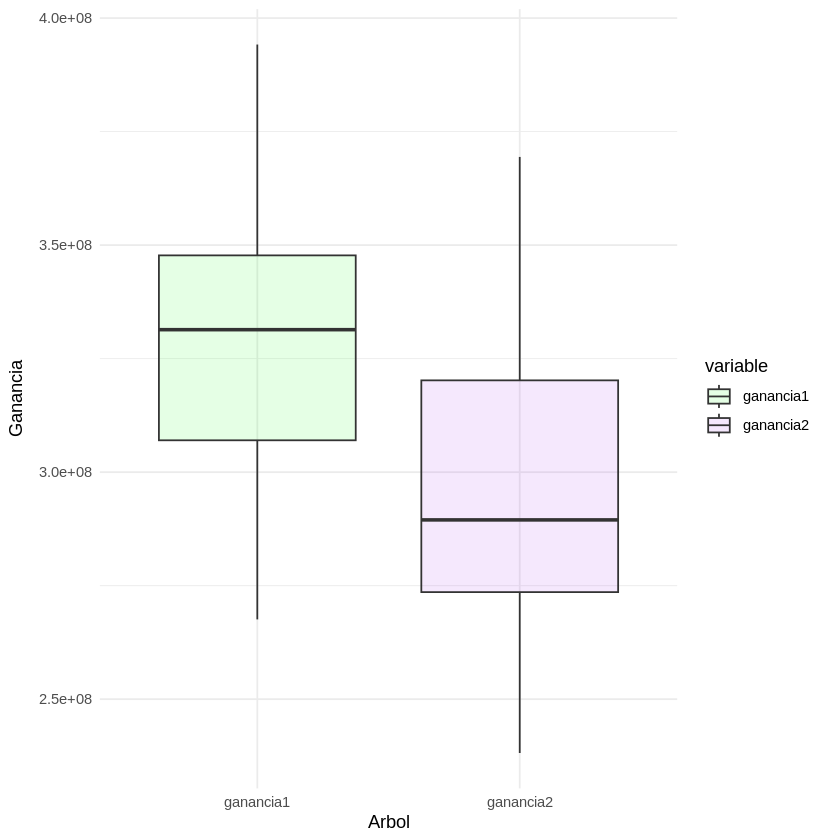

In [ ]:
gra_boxplot <- ggplot( tb_unificado, aes(x=variable, y=value, fill=variable) )+
  geom_boxplot() +
  scale_fill_manual(values = alpha( c("green", "purple"), 0.10)) +
  labs(x = "Arbol", y = "Ganancia") +
  theme_minimal()

print(gra_boxplot)

In [ ]:
# imprimo BoxPlot a .pdf
pdf("boxplot_dos.pdf")
print(gra_boxplot)
dev.off()

agg_record_10315c9181e9 
                      2

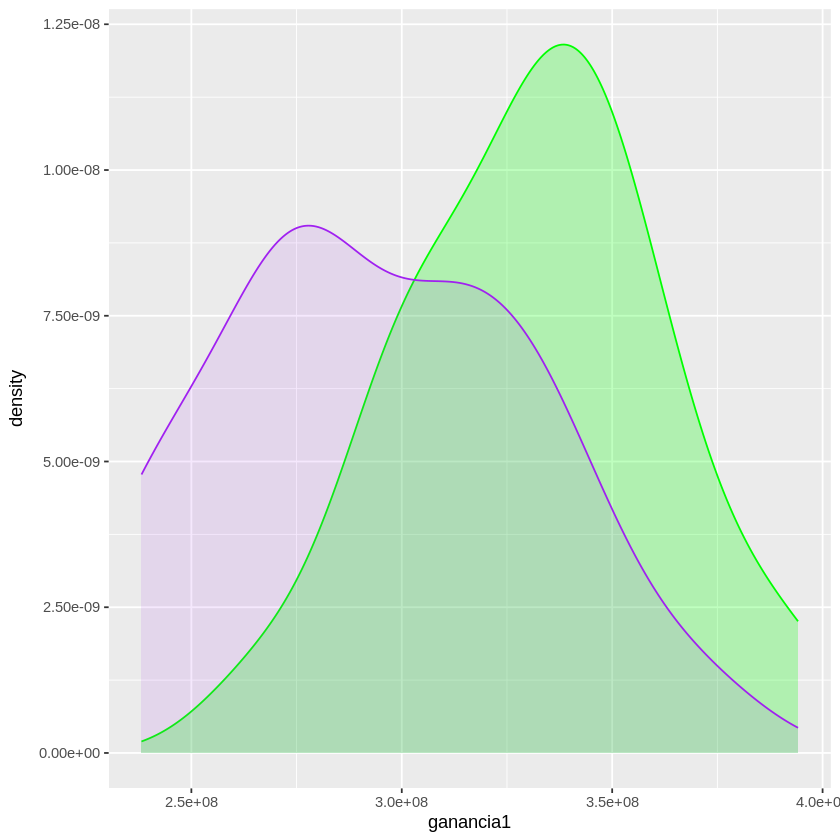

In [ ]:
gra_densidad <- ggplot( tb_salida, aes(x=ganancia1)) + geom_density(alpha=0.25, fill="green", color="green")  +
  geom_density(data=tb_salida, aes(x=ganancia2), fill="purple", color="purple",  alpha=0.10)

print(gra_densidad)

In [ ]:
# imprimo en un .pdf  que va a la carpeta del experimento
pdf("densidad_dos.pdf")
print(gra_densidad)
dev.off()

agg_record_103171b1534c 
                      2

In [ ]:
print( tb_salida[ , list( "arbol1" = mean( ganancia1),  "arbol2" = mean(ganancia2) ) ] )

print( tb_salida[ , list( "prob( m1 > m2)" = sum(ganancia1 > ganancia2 )/ .N ) ]  )

      arbol1    arbol2
       <num>     <num>
1: 331549167 294089583
   prob( m1 > m2)
            <num>
1:           0.85


### Acciones a realizar
* Reportar la  los resultados en la planilla colaborativa hoja  **C2-dosModelos**
* ¿Todos los alumnos hubieran elegido el mismo modelo aun con 20 semillas?



---



# 6 Comparando dos buenos  modelos
## Clase 02  Experimento 6

## 6.1  Objetivos
Presentar a los alumnos la dificultad que surge en la comparación de dos muy distintos, pero ambos buenos, modelos predictivos, y el costo computacional asociado a esa comparación
<br>Comparación simple de media de ganancias, versus probabilidad que un modelo sea superior a otro.
<br>Limitaciones de la MonteCarlo Cross Validation
<br>Existencia del Test de Wilcoxon

## 6.2 Introduccion
Estos son los dos arboles de muy distinta profundidad.
<br>¿Cuál de ellos es mejor? ¿Cuál elijo?

| Hiperparámetro | Arbol 1 | Arbol 2 |
| --- | --: |  ---: |
| cp | -1 | -1 |
|minsplit | 700 | 115 |
|minbucket | 350 | 5 |
|maxdepth | 8 | 6 |



## 6.3 Dos buenos modelos

Esta parte se debe correr con el runtime en lenguaje **R** Ir al menu, Runtime -> Change Runtime Type -> Runtime type -> R

El tiempo de corrida es de alrededor de 50 minutos

limpio el ambiente de R

In [4]:
# limpio la memoria
rm(list=ls(all.names=TRUE)) # remove all objects
gc(full=TRUE, verbose=FALSE) # garbage collection

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,740930,39.6,1473300,78.7,1473300,78.7
Vcells,1389972,10.7,170859661,1303.6,212615883,1622.2


* Instalacion de la libreria  rpart.plot  para dibujar el arbol
* invocacion de las librerias  **data.table** y  **rpart**

In [5]:
# cargo las librerias que necesito
require("data.table")
require("rpart")
require("parallel")

if(!require("R.utils")) install.packages("R.utils")
require("R.utils")

if (!require("primes")) install.packages("primes")
require("primes")

require("ggplot2")

Loading required package: rpart

Loading required package: parallel

Loading required package: R.utils

Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
“there is no package called ‘R.utils’”
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘R.oo’, ‘R.methodsS3’


Loading required package: R.utils

Loading required package: R.oo

Loading required package: R.methodsS3

R.methodsS3 v1.8.2 (2022-06-13 22:00:14 UTC) successfully loaded. See ?R.methodsS3 for help.

R.oo v1.27.1 (2025-05-02 21:00:05 UTC) successfully loaded. See ?R.oo for help.


Attaching package: ‘R.oo’


The following object is masked from ‘package:R.methodsS3’:

    throw


The following objects are masked from ‘package:methods’:

    getClasses, getMethods


The following objects are masked from ‘package:base’:

    attach, detach, load, save


R.utils v2.13.0 (2025-02-24 21:20:02 UTC) successfully lo

###  Accion a Realizar
PARAM$semilla_primigenia  debe reemplazarse por SU primer semilla

In [6]:
PARAM <- list()
PARAM$semilla_primigenia <- 230047
PARAM$qsemillas <- 50
PARAM$training_pct <- 70L     # entre 1 y 100


In [7]:
# los dos arboles
PARAM$rpart1 <- list (
  "cp" = -1,
  "minsplit" = 750,
  "minbucket" = 350,
  "maxdepth" = 8
)


PARAM$rpart2 <- list (
  "cp" = -1,
  "minsplit" = 115,
  "minbucket" = 5,
  "maxdepth" = 6
)


In [8]:
# particionar agrega una columna llamada fold a un dataset
#  que consiste en una particion estratificada segun agrupa

# particionar( data=dataset, division=c(70,30),
#  agrupa=clase_ternaria, seed=semilla)   crea una particion 70, 30

particionar <- function(
    data, division, agrupa = "",
    campo = "fold", start = 1, seed = NA) {
  if (!is.na(seed)) set.seed(seed)

  bloque <- unlist(mapply(function(x, y) {
    rep(y, x)
  }, division, seq(from = start, length.out = length(division))))

  data[, (campo) := sample(rep(bloque, ceiling(.N / length(bloque))))[1:.N],
    by = agrupa
  ]
}


In [9]:
DosArbolesEstimarGanancia <- function(semilla, training_pct, param_rpart1, param_rpart2) {
  # fuerzo impresion
  print( paste( semilla, Sys.time()) )
  flush.console()

  # particiono estratificadamente el dataset
  particionar(dataset,
    division = c(training_pct, 100L -training_pct),
    agrupa = "clase_ternaria",
    seed = semilla # aqui se usa SU semilla
  )

  # genero el modelo
  # predecir clase_ternaria a partir del resto
  modelo1 <- rpart("clase_ternaria ~ .",
    data = dataset[fold == 1], # fold==1  es training,  el 70% de los datos
    xval = 0,
    control = param_rpart1
  ) # aqui van los parametros del arbol

  # aplico el modelo a los datos de testing
  prediccion1 <- predict(modelo1, # el modelo que genere recien
    dataset[fold == 2], # fold==2  es testing, el 30% de los datos
    type = "prob"
  ) # type= "prob"  es que devuelva la probabilidad


  # calculo la ganancia en testing  qu es fold==2
  ganancia_test1 <- dataset[
    fold == 2,
    sum(ifelse(prediccion1[, "BAJA+2"] > 0.025,
      ifelse(clase_ternaria == "BAJA+2", 1072500, -27500),
      0
    ))
  ]

  # escalo la ganancia como si fuera todo el dataset
  ganancia_test_normalizada1 <- ganancia_test1 / (( 100 - training_pct ) / 100 )

  modelo2 <- rpart("clase_ternaria ~ .",
    data = dataset[fold == 1], # fold==1  es training,  el 70% de los datos
    xval = 0,
    control = param_rpart2
  ) # aqui van los parametros del arbol

  # aplico el modelo a los datos de testing
  prediccion2 <- predict(modelo2, # el modelo que genere recien
    dataset[fold == 2], # fold==2  es testing, el 30% de los datos
    type = "prob"
  ) # type= "prob"  es que devuelva la probabilidad


  # calculo la ganancia en testing  qu es fold==2
  ganancia_test2 <- dataset[
    fold == 2,
    sum(ifelse(prediccion2[, "BAJA+2"] > 0.025,
      ifelse(clase_ternaria == "BAJA+2", 1072500, -27500),
      0
    ))
  ]

  # escalo la ganancia como si fuera todo el dataset
  ganancia_test_normalizada2 <- ganancia_test2 / (( 100 - training_pct ) / 100 )

  return(list(
    "semilla" = semilla,
    "ganancia1" = ganancia_test_normalizada1,
    "ganancia2" = ganancia_test_normalizada2
  ))
}

In [10]:
# carpeta de trabajo
setwd("/content/buckets/b1/exp")
experimento <- "exp0206"
dir.create(experimento, showWarnings=FALSE)
setwd( paste0("/content/buckets/b1/exp/", experimento ))

In [11]:
# lectura del dataset
dataset <- fread("/content/datasets/competencia_01.csv.gz")
nrow(dataset)

[1] 983061

In [12]:
# trabajo solo con los datos de 202106, ultimo mes con clase_ternaria completa
# filtro datos
dataset <- dataset[foto_mes==202106]

invisible(gc(full=TRUE, verbose=FALSE)) # garbage collection

nrow(dataset)
dataset[, .N, list(foto_mes,clase_ternaria)]

[1] 164114

foto_mes,clase_ternaria,N
<int>,<chr>,<int>
202106,CONTINUA,162142
202106,BAJA+2,1098
202106,BAJA+1,874


In [13]:
# genero numeros primos
primos <- generate_primes(min = 100000, max = 1000000)
set.seed(PARAM$semilla_primigenia) # inicializo

# me quedo con PARAM$qsemillas   semillas
PARAM$semillas <- sample(primos, PARAM$qsemillas )

In [14]:
# la funcion mcmapply  llama a la funcion DosArbolesEstimarGanancia
#  tantas veces como valores tenga el vector  PARAM$semillas
Sys.time()

salidas <- mcmapply( DosArbolesEstimarGanancia,
  PARAM$semillas, # paso el vector de semillas
  MoreArgs = list(PARAM$training_pct, PARAM$rpart1, PARAM$rpart2), # aqui paso el segundo parametro
  SIMPLIFY = FALSE,
  mc.cores = detectCores()
)

Sys.time()

[1] "2026-08-27 13:33:54 UTC"

[1] "2026-08-27 15:18:56 UTC"

In [15]:
# paso la lista a vector
tb_salida <- rbindlist(salidas)
tb_salida

semilla,ganancia1,ganancia2
<int>,<dbl>,<dbl>
389713,360158333,389583333
620377,407641667,409933333
736889,373083333,368591667
696107,358050000,378125000
671779,275825000,278758333
655541,366391667,313316667
582251,287925000,347508333
886181,340725000,363550000
891601,309741667,326150000


Warning message in fortify(data, ...):
“Arguments in `...` must be used.
✖ Problematic arguments:
• fill = "green"
• color = "green"
ℹ Did you misspell an argument name?”


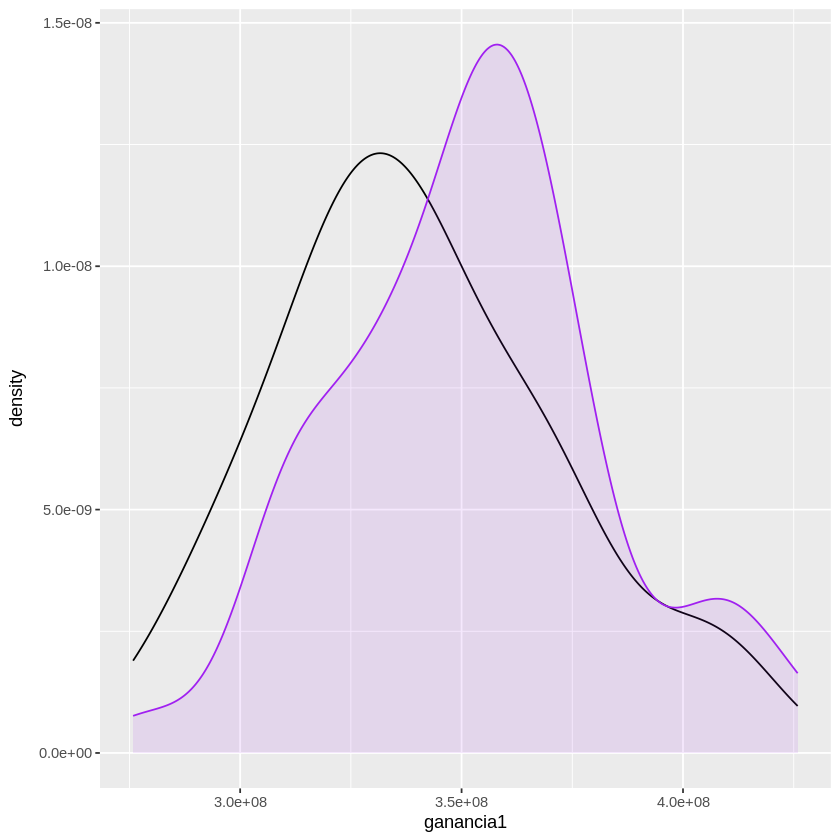

In [16]:
grafico <- ggplot( tb_salida, aes(x=ganancia1), fill="green", color="green") + geom_density(alpha=0.25)  +
             geom_density(data=tb_salida, aes(x=ganancia2), fill="purple", color="purple",  alpha=0.10)

print(grafico)

In [17]:
# imprimo en un .pdf  que va a la carpeta del experimento
pdf("densidad_dos.pdf")
print(grafico)
dev.off()

agg_record_6ad1bcc3224 
                     2

In [18]:
# medias de las ganancias
print( tb_salida[ , list( "arbol1" = mean( ganancia1),  "arbol2" = mean(ganancia2) ) ] )


      arbol1    arbol2
       <num>     <num>
1: 340176833 352595833


In [19]:
# probabilidad que m1 sea mayor a m2
print( tb_salida[ , list( "prob( m1 > m2)" = sum(ganancia1 > ganancia2 )/ .N ) ]  )

   prob( m1 > m2)
            <num>
1:           0.32


### Acciones a realizar
* Reportar la  los resultados en la planilla colaborativa hoja  **C2-dosBuenos**


# 7 Test de Wilcoxon
## Clase 02  Experimento 7

## 7.1  Objetivos

¿Como calcular la cantidad mínima de semillas que hacen falta para tener cierta certeza que un modelo es superior a otro?

## 7.2  Introduccion

| Hiperparámetro | Arbol 1 | Arbol 2 |
| --- | --: |  ---: |
| cp | -1 | -1 |
|minsplit | 170 | 250 |
|minbucket | 70 | 125 |
|maxdepth | 7 | 20 |

<br>
<br>



## 7.3 Codigo Test de Wilcoxon

In [20]:
# 1 sola ganancia
wilcox.test(
  tb_salida[1:1, ganancia1],
  tb_salida[1:1, ganancia2],
  paired = TRUE
)



	Wilcoxon signed rank exact test

data:  tb_salida[1:1, ganancia1] and tb_salida[1:1, ganancia2]
V = 0, p-value = 1
alternative hypothesis: true location shift is not equal to 0


In [21]:
# 2 ganancias
wilcox.test(
  tb_salida[1:2, ganancia1],
  tb_salida[1:2, ganancia2],
  paired = TRUE
)



	Wilcoxon signed rank exact test

data:  tb_salida[1:2, ganancia1] and tb_salida[1:2, ganancia2]
V = 0, p-value = 0.5
alternative hypothesis: true location shift is not equal to 0


In [22]:
for( i in 1:50)
{
  w <- wilcox.test(
     tb_salida[1:i, ganancia1],
     tb_salida[1:i, ganancia2],
     paired = TRUE
    )
  cat( i, w$p.value, "\n")
}

1 1 
2 0.5 
3 0.75 
4 0.375 
5 0.3125 
6 0.84375 
7 0.46875 
8 0.3125 
9 0.203125 
10 0.1308594 
11 0.1015625 
12 0.1762695 
13 0.1464844 
14 0.09057617 
15 0.2523804 
16 0.3483887 
17 0.2633209 
18 0.2462082 
19 0.4180412 
20 0.5216732 
21 0.7853651 
22 0.6101518 
23 0.4100397 
24 0.3165123 
25 0.2303613 
26 0.1650889 
27 0.1286004 
28 0.09002415 
29 0.05919633 
30 0.04265171 
31 0.02892655 
32 0.0194481 
33 0.05058562 
34 0.03742746 
35 0.03561751 
36 0.06923983 
37 0.1365538 
38 0.09864871 
39 0.07044034 
40 0.05308265 
41 0.07568453 
42 0.06022618 
43 0.07078218 
44 0.06928255 
45 0.05020205 
46 0.03916137 
47 0.02424322 
48 0.01476118 
49 0.01063008 
50 0.007075606 




---



# 8 Comparando automaticamente modelos con test de Wilcoxon
## Clase 02  Experimento 8

## 8.1  Objetivos

Proveer un script que permita comparar dos arboles de decisión con la librería rpart utilizando la menor cantidad de cómputo que permita el Test de Wilxcoxon

## 8.2  Introduccion

| Hiperparámetro | Arbol 1 | Arbol 2 |
| --- | --- |  --- |
| cp | -1 | -1 |
|minsplit | 1050 | 650 |
|minbucket | 550 | 300 |
|maxdepth |67 | 6 |




## 8.3 Codigo comparacion automatica Wilcoxon

Esta parte se debe correr con el runtime en lenguaje **R** Ir al menu, Runtime -> Change Runtime Type -> Runtime type -> R

limpio el ambiente de R

In [23]:
# limpio la memoria
rm(list=ls(all.names=TRUE)) # remove all objects
gc(full=TRUE, verbose=FALSE) # garbage collection

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,1530986,81.8,2527914,135.1,2527914,135.1
Vcells,2835642,21.7,128101405,977.4,212615883,1622.2


* Instalacion de la libreria  rpart.plot  para dibujar el arbol
* invocacion de las librerias  **data.table** y  **rpart**

In [24]:
# cargo las librerias que necesito
require("data.table")
require("rpart")
require("parallel")

if(!require("R.utils")) install.packages("R.utils")
require("R.utils")

if (!require("primes")) install.packages("primes")
require("primes")

require("ggplot2")

###  Accion a Realizar
PARAM$semilla_primigenia  debe reemplazarse por SU primer semilla

In [43]:
PARAM <- list()
# PARAM$semilla_primigenia <- 230047
PARAM$semilla_primigenia <- 230059 #La semilla anterior termina sin nunca dar p<0.05
PARAM$qsemillas_tope <- 50
PARAM$training_pct <- 70L     # entre 1 y 100


In [44]:
# los dos arboles
PARAM$rpart1 <- list (
  "cp" = -1,
  "minsplit" = 800,
  "minbucket" = 400,
  "maxdepth" = 7
)


PARAM$rpart2 <- list (
  "cp" = -1,
  "minsplit" = 650,
  "minbucket" = 300,
  "maxdepth" = 6
)


In [45]:
# particionar agrega una columna llamada fold a un dataset
#  que consiste en una particion estratificada segun agrupa

# particionar( data=dataset, division=c(70,30),
#  agrupa=clase_ternaria, seed=semilla)   crea una particion 70, 30

particionar <- function(
    data, division, agrupa = "",
    campo = "fold", start = 1, seed = NA) {
  if (!is.na(seed)) set.seed(seed)

  bloque <- unlist(mapply(function(x, y) {
    rep(y, x)
  }, division, seq(from = start, length.out = length(division))))

  data[, (campo) := sample(rep(bloque, ceiling(.N / length(bloque))))[1:.N],
    by = agrupa
  ]
}


In [46]:
DosArbolesEstimarGanancia <- function(semilla, training_pct, param_rpart1, param_rpart2) {
  # particiono estratificadamente el dataset
  particionar(dataset,
    division = c(training_pct, 100L -training_pct),
    agrupa = "clase_ternaria",
    seed = semilla # aqui se usa SU semilla
  )

  # genero el modelo
  # predecir clase_ternaria a partir del resto
  modelo1 <- rpart("clase_ternaria ~ .",
    data = dataset[fold == 1], # fold==1  es training,  el 70% de los datos
    xval = 0,
    control = param_rpart1
  ) # aqui van los parametros del arbol

  # aplico el modelo a los datos de testing
  prediccion1 <- predict(modelo1, # el modelo que genere recien
    dataset[fold == 2], # fold==2  es testing, el 30% de los datos
    type = "prob"
  ) # type= "prob"  es que devuelva la probabilidad


  # calculo la ganancia en testing  qu es fold==2
  ganancia_test1 <- dataset[
    fold == 2,
    sum(ifelse(prediccion1[, "BAJA+2"] > 0.025,
      ifelse(clase_ternaria == "BAJA+2", 1072500, -27500),
      0
    ))
  ]

  # escalo la ganancia como si fuera todo el dataset
  ganancia_test_normalizada1 <- ganancia_test1 / (( 100 - training_pct ) / 100 )

  modelo2 <- rpart("clase_ternaria ~ .",
    data = dataset[fold == 1], # fold==1  es training,  el 70% de los datos
    xval = 0,
    control = param_rpart2
  ) # aqui van los parametros del arbol

  # aplico el modelo a los datos de testing
  prediccion2 <- predict(modelo2, # el modelo que genere recien
    dataset[fold == 2], # fold==2  es testing, el 30% de los datos
    type = "prob"
  ) # type= "prob"  es que devuelva la probabilidad


  # calculo la ganancia en testing  qu es fold==2
  ganancia_test2 <- dataset[
    fold == 2,
    sum(ifelse(prediccion2[, "BAJA+2"] > 0.025,
      ifelse(clase_ternaria == "BAJA+2", 1072500, -27500),
      0
    ))
  ]

  # escalo la ganancia como si fuera todo el dataset
  ganancia_test_normalizada2 <- ganancia_test2 / (( 100 - training_pct ) / 100 )

  return(list(
    "semilla" = semilla,
    "ganancia1" = ganancia_test_normalizada1,
    "ganancia2" = ganancia_test_normalizada2
  ))
}

In [47]:
# 1  ->  el modelo 1 es mejor
# 2  ->  el modelo 2 es mejor
# 0  ->  No se pudo determinar con el tope de qsemillas_tope


MejorArbol <- function( qsemillas_tope, training_pct, param_rpart1, param_rpart2) {

  # genero numeros primos
  primos <- generate_primes(min = 100000, max = 1000000)
  set.seed(PARAM$semilla_primigenia) # inicializo
  # me quedo con PARAM$qsemillas   semillas
  semillas <- sample(primos, qsemillas_tope )

  pvalue <- 1.0
  isem <- 1
  vgan1 <- c() # almaceno ganancias del modelo1
  vgan2 <- c() # almaceno ganancias del modelo2

  while( (isem <= qsemillas_tope)  & (pvalue > 0.05) ) {

    res <- DosArbolesEstimarGanancia(
       semillas[ isem ],
       training_pct,
       param_rpart1,
       param_rpart2
    )

    vgan1 <- c( vgan1, res$ganancia1 )
    vgan2 <- c( vgan2, res$ganancia2 )

    wt <- wilcox.test( vgan1, vgan2, paired=TRUE )
    pvalue <- wt$p.value

    cat( isem, res$ganancia1, res$ganancia2, pvalue, "\n" )
    flush.console()
    isem <- isem + 1
  }

  out <- 0

  if( pvalue < 0.05 & mean(vgan1) > mean(vgan2)  )  out <- 1
  if( pvalue < 0.05 & mean(vgan1) < mean(vgan2)  )  out <- 2


  return( list( "out" = out,
    "qsemillas" = length(vgan1),
    "m1" = mean( vgan1 ),
    "m2" = mean( vgan2 )
   ) )
}


In [48]:
# carpeta de trabajo
setwd("/content/buckets/b1/exp")
experimento <- "exp0208"
dir.create(experimento, showWarnings=FALSE)
setwd( paste0("/content/buckets/b1/exp/", experimento ))

In [49]:
# lectura del dataset
dataset <- fread("/content/datasets/competencia_01.csv.gz")
nrow(dataset)

[1] 983061

In [50]:
# trabajo solo con los datos de 202106, ultimo mes con clase_ternaria completa
# filtro datos
dataset <- dataset[foto_mes==202106]

invisible(gc(full=TRUE, verbose=FALSE)) # garbage collection

nrow(dataset)
dataset[, .N, list(foto_mes,clase_ternaria)]

[1] 164114

foto_mes,clase_ternaria,N
<int>,<chr>,<int>
202106,CONTINUA,162142
202106,BAJA+2,1098
202106,BAJA+1,874


In [51]:
Sys.time()

comparacion <- MejorArbol(
   PARAM$qsemillas_tope,
   PARAM$training_pct,
   PARAM$rpart1,
   PARAM$rpart2
 )


print( comparacion )

Sys.time()

[1] "2026-08-27 17:16:26 UTC"

1 354291667 343200000 1 
2 320466667 317258333 0.5 
3 380141667 411308333 1 
4 389491667 392241667 1 
5 373083333 373541667 1 
6 294250000 269408333 0.84375 
7 357041667 359058333 0.9375 
8 393250000 341366667 0.546875 
9 3.85e+08 378216667 0.359375 
10 343200000 334950000 0.2324219 
11 368408333 324500000 0.1230469 
12 323583333 299475000 0.07714844 
13 379500000 337150000 0.03979492 
$out
[1] 1

$qsemillas
[1] 13

$m1
[1] 358592949

$m2
[1] 344744231



[1] "2026-08-27 17:44:54 UTC"

### Acciones a realizar
* Reportar la  los resultados en la planilla colaborativa hoja  **C2-Wilcox**




---

